# S01 — F9 benchmark harness

**Goal.** Build a dispatcher so every candidate can be benchmarked with a single command.

**Outcome.** A working `CoregResult` contract, `@register_candidate` registry, `run_candidate(id, subject)` function, and aggregated `bench_results.csv`.

The reference candidate `REF_GT` short-circuits by copying the ground-truth coreg table — a 100% recall sanity check.

In [1]:
import sys, os
from pathlib import Path
ROOT = Path('/root/capsule/code/full_automatic_execution_01').resolve()
sys.path.insert(0, str(ROOT))
sys.path.insert(0, '/root/capsule/code/dev_code')

from bench import candidates  # triggers registration
from bench.harness import CANDIDATES, run_candidate, BENCHMARK_SUBJECTS
print('Registered candidates:', list(CANDIDATES))
print('Benchmark subjects:', BENCHMARK_SUBJECTS)

Registered candidates: ['REF_GT']
Benchmark subjects: ['755252', '767018', '767022', '782149', '788406', '790322']


In [2]:
import pandas as pd

# Clear the aggregated CSV for a clean demo
bench_csv = ROOT / 'bench_out' / 'bench_results.csv'
if bench_csv.exists():
    bench_csv.unlink()

rows = []
for sid in BENCHMARK_SUBJECTS:
    try:
        rows.append(run_candidate('REF_GT', sid))
    except Exception as e:
        rows.append({'candidate_id': 'REF_GT', 'subject_id': sid, 'error': str(e)})
pd.DataFrame(rows)

,candidate_id,subject_id,runtime_s,load_s,confidence,n_gt,n_pred,recall,precision,recall_at_5um,recall_at_10um,recall_at_20um,median_error_um,p95_error_um,landmark_n,landmark_rms_um,landmark_origin_err_um,landmark_rotation_deg_z,error
0,REF_GT,755252,0.007,3.957,1.0,639,639,1.0,1.0,1.0,1.0,1.0,0.0,0.0,647,1277.288100,1205.255269,0.0,None
1,REF_GT,767018,0.005,12.237,1.0,273,273,1.0,1.0,1.0,1.0,1.0,0.0,0.0,574,1482.006977,1403.694772,0.0,None
2,REF_GT,767022,0.005,2.150,1.0,793,793,1.0,1.0,1.0,1.0,1.0,0.0,0.0,789,1386.014505,1301.332398,0.0,None
3,REF_GT,782149,0.004,1.567,1.0,303,303,1.0,1.0,1.0,1.0,1.0,0.0,0.0,317,1561.737414,1485.202894,0.0,None
4,REF_GT,788406,0.005,2.771,1.0,787,787,1.0,1.0,1.0,1.0,1.0,0.0,0.0,604,1562.801968,1483.286388,0.0,None
5,REF_GT,790322,0.004,3.285,1.0,778,778,1.0,1.0,1.0,1.0,1.0,0.0,0.0,437,1434.635875,1345.091600,0.0,None


In [3]:
import pandas as pd, matplotlib.pyplot as plt
df = pd.read_csv(bench_csv)
df[['subject_id','recall','recall_at_5um','recall_at_10um','recall_at_20um','n_gt','n_pred']]

,subject_id,recall,recall_at_5um,recall_at_10um,recall_at_20um,n_gt,n_pred
0,755252,1.0,1.0,1.0,1.0,639,639
1,767018,1.0,1.0,1.0,1.0,273,273
2,767022,1.0,1.0,1.0,1.0,793,793
3,782149,1.0,1.0,1.0,1.0,303,303
4,788406,1.0,1.0,1.0,1.0,787,787
5,790322,1.0,1.0,1.0,1.0,778,778


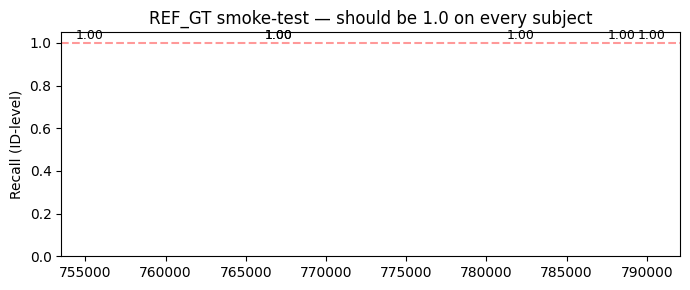

In [4]:
fig, ax = plt.subplots(figsize=(7,3))
ax.bar(df['subject_id'], df['recall'], color='tab:blue', alpha=0.8)
ax.set_ylabel('Recall (ID-level)'); ax.set_ylim(0,1.05)
ax.set_title('REF_GT smoke-test — should be 1.0 on every subject')
ax.axhline(1.0, color='r', ls='--', alpha=0.4)
for sid, r in zip(df['subject_id'], df['recall']):
    ax.text(sid, r+0.02, f'{r:.2f}', ha='center', fontsize=9)
fig.tight_layout()
fig.savefig(str(ROOT/'sessions'/'01_F9_benchmark_harness'/'figures'/'ref_gt_recall.png'), dpi=120)
plt.show()

## API summary

```python
from bench.harness import CoregResult, TransformDescriptor, register_candidate, run_candidate

@register_candidate('MyID')
def run(s):
    pairs = pd.DataFrame({
        'cz_id': [...], 'hcr_id': [...], 'confidence': [...],
        'cz_x_um': [...], 'cz_y_um': [...], 'cz_z_um': [...],
        'hcr_x_um': [...], 'hcr_y_um': [...], 'hcr_z_um': [...],
    })
    return CoregResult(pairs_df=pairs, confidence=<overall_scalar>)
```

## Files

- `bench/harness.py`
- `bench/candidates.py`
- `bench/candidate_impls/_ref_identity.py`
- `run_candidate.py` (top-level CLI)